In [51]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

In [52]:
class IntegratorOde():
    def __init__(self, u0: np.array):
        self.u0=u0

    def odes(self, u, t):
        x1, x2, v1, v2, a1, a2=u[:]
        dot=(
            v1, v2, 
            a1, a2, 
            -2*v2*v2+x2, -a1*a1*a1+v2 + x1 + np.sin(t)
        )
        return dot

    def reset_u0(self, u0_t0: np.array =None):
        if u0_t0 != None:
            self.u0=u0_t0


    def evolution(self, T, dt=0.001, t0=0.):
        # Prepare t, the sampling times
        t_ = np.arange(t0, T, dt)
        # Solve the ODEs
        u = odeint(self.odes, self.u0, t_, 
                #    args=tuple(self.params),
                    printmessg=True
                    )
        return u

    def display_evolution(self, T, dt=0.001, t0=0.):
        u=self.evolution( T, dt=dt, t0=t0)
        t_ = np.arange(t0, T, dt)

        dictionary={'x1': {'title': "X1 evolution", 'var' : (t_, u[:, 0]), 'color': 'blue'},
                    'v1':  {'title': "V1 evolution", 'var' : (t_, u[:, 2]), 'color': 'orange'},
                    'a1':  {'title': "A1 evolution", 'var' : (t_, u[:, 4]), 'color': 'lime'},                    
                    'x2':  {'title': "X2 evolution", 'var' : (t_, u[:, 1]), 'color': 'red'},
                    'v2': {'title': "V2 evolution", 'var': (t_, u[:, 3] ), 'color': 'black' },
                    'a2': {'title': "A2 evolution", 'var': (t_, u[:, 5] ), 'color': 'violet' }
                    }
        args=['x1', 'v1', 'a1', 'x2', 'v2', 'a2']
        fig, axes=plt.subplots(2, 3, figsize=(9, 6))
        print(type(axes), axes.shape)
        for key, ax in zip(args, axes.flat):
            # print(type(ax))
            ax.set_title(dictionary[key]['title'])

            ax.set_ylabel(key)

            ax.plot(dictionary[key]['var'][0], dictionary[key]['var'][1], '.', ms=3, color=dictionary[key]['color'])
            ax.set_xlabel("t")
            ax.grid()

        plt.tight_layout()
        plt.show()




C:\Users\mrtlu\AppData\Local\Temp\ipykernel_23572\4014264468.py:23: ODEintWarning: Integration successful.
  u = odeint(self.odes, self.u0, t_,


<class 'numpy.ndarray'> (2, 3)


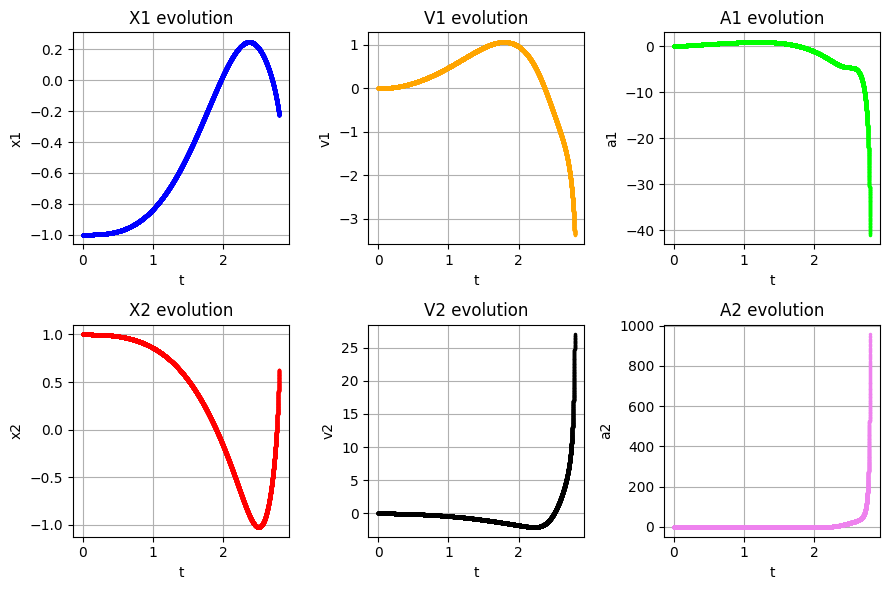

In [53]:
x10, x20, v10, v20, a10, a20 = -1, 1, 0, 0, 0,0

int=IntegratorOde(np.array([x10, x20, v10, v20, a10, a20])) 
T=2.8
int.display_evolution(T, 0.0001)

In [65]:
class IntegratorOde_generic():
    def __init__(self,  u0: np.array, alpha: float=-2.0, ft=np.sin,):
        self.ft=ft
        self.u0=u0
        self.param=alpha
    def odes(self, u, t, param, ft):
        x1, x2, v1, v2, a1, a2=u[:]
        dot=(
            v1, v2, 
            a1, a2, 
            param*v2*v2+x2, param/2. *a1*a1*a1+v2 + x1 + ft(t)
        )
        return dot

    def reset_u0(self, u0_t0: np.array =None):
        if u0_t0 != None:
            self.u0=u0_t0


    def evolution(self, T, dt=0.001, t0=0.):
        # Prepare t, the sampling times
        t_ = np.arange(t0, T, dt)
        # Solve the ODEs
        u = odeint(self.odes, self.u0, t_, 
                    args=tuple([self.param, self.ft]),
                    printmessg=True
                    )
        return u

    def display_evolution(self, T, dt=0.001, t0=0.):
        u=self.evolution( T, dt=dt, t0=t0)
        t_ = np.arange(t0, T, dt)

        dictionary={'x1': {'title': "X1 evolution", 'var' : (t_, u[:, 0]), 'color': 'blue'},
                    'v1':  {'title': "V1 evolution", 'var' : (t_, u[:, 2]), 'color': 'orange'},
                    'a1':  {'title': "A1 evolution", 'var' : (t_, u[:, 4]), 'color': 'lime'},                    
                    'x2':  {'title': "X2 evolution", 'var' : (t_, u[:, 1]), 'color': 'red'},
                    'v2': {'title': "V2 evolution", 'var': (t_, u[:, 3] ), 'color': 'black' },
                    'a2': {'title': "A2 evolution", 'var': (t_, u[:, 5] ), 'color': 'violet' }
                    }
        args=['x1', 'v1', 'a1', 'x2', 'v2', 'a2']
        fig, axes=plt.subplots(2, 3, figsize=(9, 6))
        print(type(axes), axes.shape)
        for key, ax in zip(args, axes.flat):
            # print(type(ax))
            ax.set_title(dictionary[key]['title'])

            ax.set_ylabel(key)

            ax.plot(dictionary[key]['var'][0], dictionary[key]['var'][1], '.', ms=3, color=dictionary[key]['color'])
            ax.set_xlabel("t")
            ax.grid()

        plt.tight_layout()
        plt.show()



In [ ]:
def f(t):
    return 0.5*np.cos(t)

C:\Users\mrtlu\AppData\Local\Temp\ipykernel_23572\527497022.py:24: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  u = odeint(self.odes, self.u0, t_,


<class 'numpy.ndarray'> (2, 3)


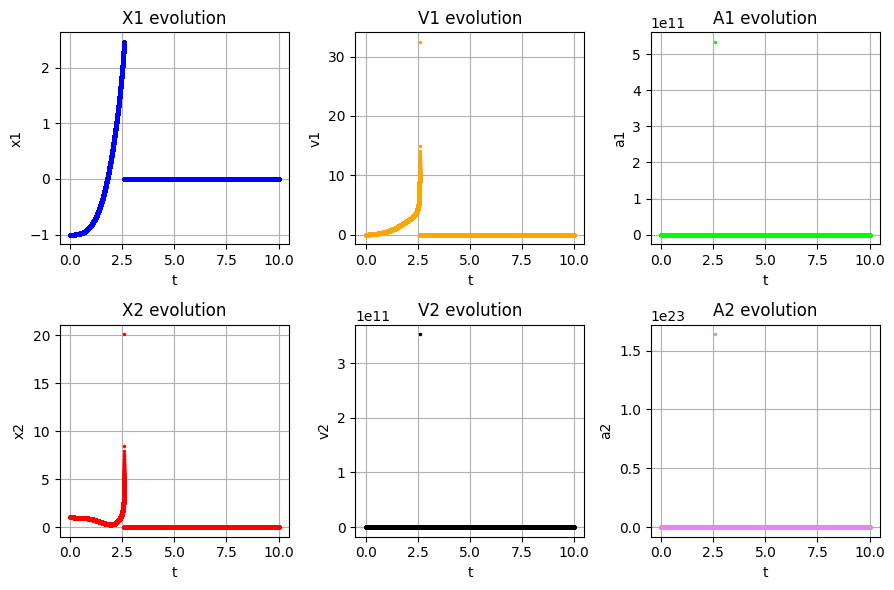

In [84]:
x10, x20, v10, v20, a10, a20 = -1, 1, 0, 0, 0,0

int=IntegratorOde_generic(np.array([x10, x20, v10, v20, a10, a20]), ft=f, alpha=2.) 
T=10
int.display_evolution(T, 0.00001)